# Sampling methods for transfer learning

Choosing a sampling method is split into 2 parts:

- What descriptor to use? E.g. bond length, bond angles. 

- What selector algorithm to use? I.e. what distribution of descriptors do we want to select?

## 0.1. Imports and load data

In [6]:
import ase.io
from pathlib import Path
import numpy as np
import importlib
import torch
import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [7]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 500  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 500 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))

base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Train base model



In [8]:
base_model_training_result = training.train_model(
    base_atoms_list,
    max_epochs=10
)

base_model = base_model_training_result.model
z_table = base_model_training_result.z_table
base_history = base_model_training_result.history
base_encoder = base_model_training_result.encoder

/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

{'stage': 'base_model', 'epoch': 1, 'train_loss': 107.93402940750121, 'valid_loss': 89.07300842285156, 'seconds': 22.0}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 25.219936113357544, 'valid_loss': 24.50059341430664, 'seconds': 27.86}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 21.637628936767577, 'valid_loss': 21.982149085998536, 'seconds': 25.29}

Training complete after 10 epochs
Final train loss: 21.637629
Final valid loss: 21.982149


In [9]:
# save model
base_model_filename = "base_model_propene_500_geometries_for_pca_testing.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
torch.save(base_model, base_model_save_path)
print(f"Base model saved to {base_model_save_path}")

Base model saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/base_models/base_model_propene_500_geometries_for_pca_testing.pt


## 1. Choose descriptor

In [83]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[6]  # choose the descriptor type to use

# matrix of descriptors for each geometry
desc_matrix = []
for atom in transfer_atoms_list:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


desc_matrix shape: (500, 765)
desc_matrix unique shape: (500, 765)
desc_matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [78]:
# Optional dimensionality reduction using PCA

PCA_DIMENSIONS = 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=PCA_DIMENSIONS)
desc_matrix = pca.fit_transform(desc_matrix_scaled)

print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 3)
desc_matrix unique shape: (500, 3)
desc_matrix:
 [[ 25.66290073  -7.5435525    3.57461524]
 [-17.68889132  -1.97186744 -11.88806588]
 [ -9.68128667   8.30790249  11.93837659]
 ...
 [ -4.73528134  13.40840203  -1.75137886]
 [ -0.93051678  -9.05129291  -4.19616038]
 [ -3.10642808 -11.28432425  -3.91061191]]


## 2. Choose selector

In [ ]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "birch", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[3]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=1)

# sampled atoms
sampled_atoms = [transfer_atoms_list[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

TypeError: dbscan() got an unexpected keyword argument 'n_clusters'

## 3. Do transfer learning 

Only testing with naive transfer learning for now.

In [ ]:
# this will overwrite the base model from the previous section
# run this to load the base model from file instead of using previous section
# base_model_filename = "base_model_propene_500_geometries.pt"
# base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
# base_model = torch.load(base_model_save_path, weights_only=False)
# base_model.eval()

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

In [85]:
# run this to use the base model from the previous section
transfer_model_training_result = training.train_model(
    sampled_atoms,
    model=base_model,
    z_table=z_table,
    max_epochs=10,
)

transfer_history = transfer_model_training_result.history
transfer_model = transfer_model_training_result.model

{'stage': 'base_model', 'epoch': 1, 'train_loss': 4.992469334602356, 'valid_loss': 3.929486846923828, 'seconds': 4.79}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 3.616384196281433, 'valid_loss': 3.604623031616211, 'seconds': 5.03}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 3.6798298478126528, 'valid_loss': 3.480644416809082, 'seconds': 5.08}

Training complete after 10 epochs
Final train loss: 3.679830
Final valid loss: 3.480644


In [ ]:
# save model
transfer_model_filename = "transfer_model_propene_100_samples.pt"
transfer_model_save_path = OUTPUT_DIR / "transfer_models" / transfer_model_filename
torch.save(transfer_model, transfer_model_save_path)
print(f"Transfer model saved to {transfer_model_save_path}")

## 4. Plots

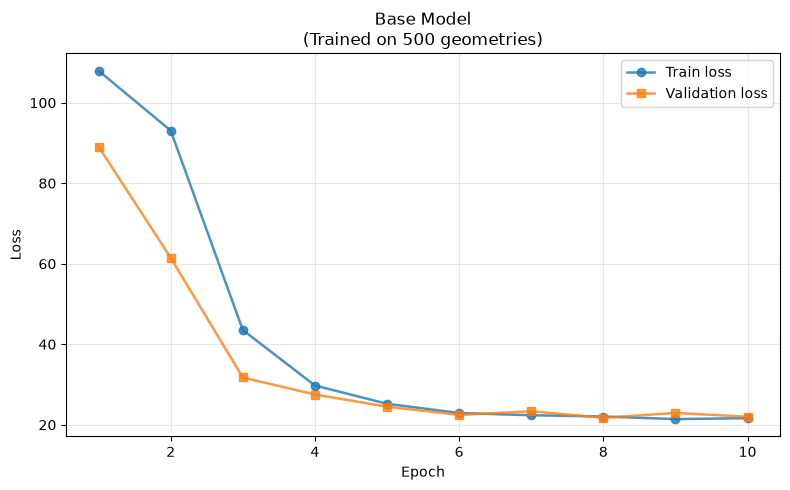

In [14]:
import matplotlib.pyplot as plt

# Plot base model training history
base_epochs = [row["epoch"] for row in base_history]
base_train_losses = [row["train_loss"] for row in base_history]
base_valid_losses = [row["valid_loss"] for row in base_history]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(base_epochs, base_train_losses, marker="o", linewidth=1.8, label="Train loss", alpha=0.8)
ax.plot(base_epochs, base_valid_losses, marker="s", linewidth=1.8, label="Validation loss", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Base Model\n(Trained on {BASE_N_GEOMETRIES} geometries)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

# save plot
# BASE_LOSS_PLOT_PATH = OUTPUT_DIR / "plots" / "base_model_propene_500_geometries.png"
# fig.savefig(BASE_LOSS_PLOT_PATH, dpi=150)

plt.show()

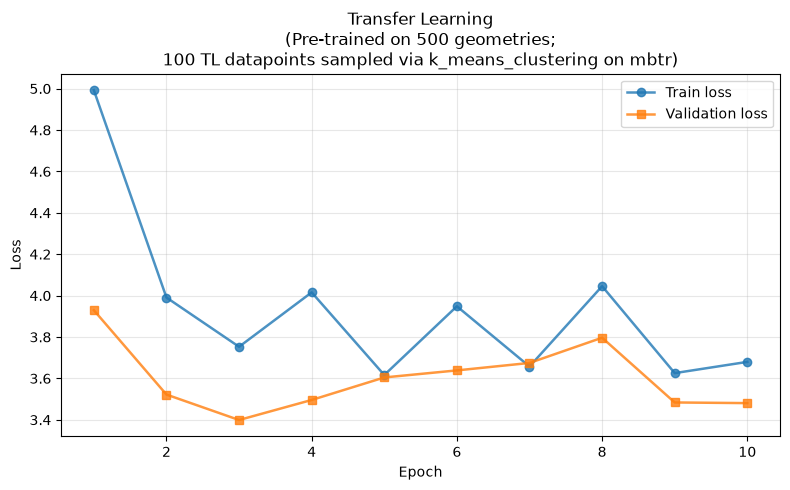

In [86]:
# Plot transfer learning training history
transfer_epochs = [row["epoch"] for row in transfer_history]
transfer_train_losses = [row["train_loss"] for row in transfer_history]
transfer_valid_losses = [row["valid_loss"] for row in transfer_history]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(transfer_epochs, transfer_train_losses, marker="o", linewidth=1.8, label="Train loss", alpha=0.8)
ax.plot(transfer_epochs, transfer_valid_losses, marker="s", linewidth=1.8, label="Validation loss", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
if SELECTOR == 'random_sampling':
    ax.set_title(f"Transfer Learning\n(Pre-trained on {BASE_N_GEOMETRIES} geometries;\n{N_SAMPLES} TL datapoints sampled via {SELECTOR})")
else:
    ax.set_title(f"Transfer Learning\n(Pre-trained on {BASE_N_GEOMETRIES} geometries;\n{N_SAMPLES} TL datapoints sampled via {SELECTOR} on {DESCRIPTOR})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

# save plot
# TRANSFER_LOSS_PLOT_PATH = OUTPUT_DIR / "plots" / "transfer_model_propene_100_samples.png"
# fig.savefig(TRANSFER_LOSS_PLOT_PATH, dpi=150)

plt.show()


In [87]:
print(np.min(transfer_valid_losses))

3.3990479946136474


## 5. Junkyard

In [ ]:
def add_autoencoder_targets(active_model, batch, output):
    """Add autoencoder targets to output for loss computation."""
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)
    
    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

In [9]:
import copy
import time
import torch
from mace import data, modules, tools
from mace.tools import torch_geometric
from e3nn import o3

DEVICE = torch.device("cpu")
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

# Base model training parameters
BASE_MODEL_MAX_EPOCHS = 50
BASE_MODEL_LR = 1.0e-3
BATCH_SIZE = 4
R_MAX = 5.0
BASE_VALID_FRACTION = 0.20

example_atom = base_atoms_list[0]
N_ENERGIES = np.asarray(example_atom.info["REF_energy"]).shape[-1]

print(f"Energy shape: {np.asarray(example_atom.info['REF_energy']).shape}")
print(f"Forces shape: {np.asarray(example_atom.info['REF_forces']).shape}")
print(f"N_ENERGIES: {N_ENERGIES}")


Energy shape: (1, 3)
Forces shape: (6, 3, 3)
N_ENERGIES: 3


In [20]:
# Create MACE Configuration objects from all atoms
base_atoms_configs = data.config_from_atoms_list(
    base_atoms_list,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

# Split into train/validation
base_train_configs, base_valid_configs = data.random_train_valid_split(
    base_atoms_configs,
    valid_fraction=BASE_VALID_FRACTION,
    seed=SEED,
    work_dir=str(OUTPUT_DIR/"random_train_valid_split"),
)

print(f"Train configs: {len(base_train_configs)}")
print(f"Valid configs: {len(base_valid_configs)}")


Train configs: 80
Valid configs: 20


In [11]:
# Create atomic number table and compute atomic energies
z_table = tools.get_atomic_number_table_from_zs(
    z for config in base_atoms_configs for z in config.atomic_numbers
)

atomic_energies_dict = data.compute_average_E0s(base_train_configs, z_table)
atomic_energies = np.array([atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64)

print(f"Atomic numbers: {[int(z) for z in z_table.zs]}")
print("Estimated E0s:", {int(k): float(v) for k, v in atomic_energies_dict.items()})

Atomic numbers: [1, 6]
Estimated E0s: {1: -423.28382858346106, 6: -211.6419142917305}


In [12]:
# Convert Configuration objects to graph data objects
base_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in base_train_configs
]
base_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in base_valid_configs
]

# Create data loaders
base_train_loader = torch_geometric.dataloader.DataLoader(
    base_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
base_valid_loader = torch_geometric.dataloader.DataLoader(
    base_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

avg_num_neighbors = modules.compute_avg_num_neighbors(base_train_loader)
print(f"Average neighbors: {float(avg_num_neighbors)}")


Average neighbors: 5.0


In [13]:
# Build the base model
base_model = modules.AutoencoderExcitedMACE(
    r_max=R_MAX,
    num_bessel=4,
    num_polynomial_cutoff=3,
    num_permutational_invariant=4,
    n_energies=N_ENERGIES,
    max_ell=2,
    interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    num_interactions=1,
    num_elements=len(z_table),
    hidden_irreps=o3.Irreps("4x0e + 4x1o"),
    MLP_irreps=o3.Irreps("4x0e"),
    atomic_energies=atomic_energies,
    avg_num_neighbors=float(avg_num_neighbors),
    atomic_numbers=[int(z) for z in z_table.zs],
    correlation=1,
    gate=modules.gate_dict["silu"],
    radial_MLP=[32, 32],
    compute_nacs=False,
    compute_socs=False,
    nac_num=0,
    soc_num=0,
).to(DEVICE)

print(f"Base model class: {base_model.__class__.__name__}")
print(f"Total parameters: {tools.count_parameters(base_model)}")


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


Base model class: AutoencoderExcitedMACE
Total parameters: 54269


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

In [14]:
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0,
    forces_weight=5.0,
    dipoles_weight=0.0,
    nacs_weight=0.0,
    socs_weight=0.0,
)

def add_autoencoder_targets(active_model, batch, output):
    """Add autoencoder targets to output for loss computation."""
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)
    
    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

optimizer = torch.optim.Adam(base_model.parameters(), lr=BASE_MODEL_LR)


In [15]:
base_history = []

for epoch in range(BASE_MODEL_MAX_EPOCHS):
    epoch_start = time.time()
    base_model.train()
    train_losses = []

    for batch in base_train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        output = base_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(base_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), max_norm=10.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    base_model.eval()
    valid_losses = []
    for batch in base_valid_loader:
        batch = batch.to(DEVICE)
        output = base_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(base_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "base_model",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    base_history.append(row)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(row)

print(f"\nBase model training complete after {BASE_MODEL_MAX_EPOCHS} epochs")
print(f"Final train loss: {base_history[-1]['train_loss']:.6f}")
print(f"Final valid loss: {base_history[-1]['valid_loss']:.6f}")


{'stage': 'base_model', 'epoch': 1, 'train_loss': 133.50133457183838, 'valid_loss': 123.0882942199707, 'seconds': 4.73}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 24.448433685302735, 'valid_loss': 28.93583164215088, 'seconds': 3.8}
{'stage': 'base_model', 'epoch': 20, 'train_loss': 20.233992409706115, 'valid_loss': 16.200241470336913, 'seconds': 3.66}
{'stage': 'base_model', 'epoch': 30, 'train_loss': 18.309427070617676, 'valid_loss': 17.055677795410155, 'seconds': 3.57}
{'stage': 'base_model', 'epoch': 40, 'train_loss': 15.904407215118407, 'valid_loss': 13.581294059753418, 'seconds': 3.66}
{'stage': 'base_model', 'epoch': 50, 'train_loss': 17.88831443786621, 'valid_loss': 16.37652168273926, 'seconds': 3.74}

Base model training complete after 50 epochs
Final train loss: 17.888314
Final valid loss: 16.376522


In [16]:
# Transfer learning parameters
TRANSFER_MAX_EPOCHS = 50
TRANSFER_LR = 5.0e-4
TRANSFER_VALID_FRACTION = 0.20

# Create MACE Configuration objects from selected atoms
transfer_configs = data.config_from_atoms_list(
    selected_atoms,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

# Split selected configurations into train/validation sets
transfer_train_configs, transfer_valid_configs = data.random_train_valid_split(
    transfer_configs,
    valid_fraction=TRANSFER_VALID_FRACTION,
    seed=SEED,
    work_dir=str(ROOT_PATH),
)

print(f"Train configs: {len(transfer_train_configs)}")
print(f"Valid configs: {len(transfer_valid_configs)}")


Train configs: 40
Valid configs: 10


In [17]:
# Convert Configuration objects to graph data objects
transfer_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in transfer_train_configs
]
transfer_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in transfer_valid_configs
]

# Create data loaders for transfer learning
transfer_train_loader = torch_geometric.dataloader.DataLoader(
    transfer_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
transfer_valid_loader = torch_geometric.dataloader.DataLoader(
    transfer_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


In [18]:
# Make a deep copy of the base model for transfer learning
transfer_model = copy.deepcopy(base_model).to(DEVICE)
transfer_model.eval()

# Initialize optimizer for naive transfer learning (all parameters trainable)
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=TRANSFER_LR)
transfer_trainable_count = sum(param.numel() for param in transfer_model.parameters() if param.requires_grad)

print(f"Transfer model class: {transfer_model.__class__.__name__}")
print(f"Transfer model parameters: {tools.count_parameters(transfer_model)}")
print(f"Transfer trainable parameters: {transfer_trainable_count}")
print(f"All parameters will be fine-tuned (naive transfer learning)")


Transfer model class: AutoencoderExcitedMACE
Transfer model parameters: 54269
Transfer trainable parameters: 54269
All parameters will be fine-tuned (naive transfer learning)


In [14]:
# Transfer learning training loop
transfer_history = []

for epoch in range(TRANSFER_MAX_EPOCHS):
    epoch_start = time.time()
    transfer_model.train()
    train_losses = []

    for batch in transfer_train_loader:
        batch = batch.to(DEVICE)
        transfer_optimizer.zero_grad(set_to_none=True)

        output = transfer_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(transfer_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transfer_model.parameters(), max_norm=10.0)
        transfer_optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    transfer_model.eval()
    valid_losses = []
    for batch in transfer_valid_loader:
        batch = batch.to(DEVICE)
        output = transfer_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(transfer_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "transfer_learning_naive",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    transfer_history.append(row)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(row)

print(f"\nTransfer learning complete after {TRANSFER_MAX_EPOCHS} epochs")
print(f"Final train loss: {transfer_history[-1]['train_loss']:.6f}")
print(f"Final valid loss: {transfer_history[-1]['valid_loss']:.6f}")


{'stage': 'transfer_learning_naive', 'epoch': 1, 'train_loss': 46.002227783203125, 'valid_loss': 77.25628662109375, 'seconds': 2.6}
{'stage': 'transfer_learning_naive', 'epoch': 10, 'train_loss': 35.377170944213866, 'valid_loss': 67.54226938883464, 'seconds': 2.42}
{'stage': 'transfer_learning_naive', 'epoch': 20, 'train_loss': 30.790317916870116, 'valid_loss': 53.913323720296226, 'seconds': 2.89}
{'stage': 'transfer_learning_naive', 'epoch': 30, 'train_loss': 28.614780044555665, 'valid_loss': 47.33015441894531, 'seconds': 2.72}
{'stage': 'transfer_learning_naive', 'epoch': 40, 'train_loss': 27.557461071014405, 'valid_loss': 44.18674087524414, 'seconds': 2.61}
{'stage': 'transfer_learning_naive', 'epoch': 50, 'train_loss': 26.280632972717285, 'valid_loss': 41.46345011393229, 'seconds': 2.54}

Transfer learning complete after 50 epochs
Final train loss: 26.280633
Final valid loss: 41.463450
